# SPY Log Returns — Benchmark Time Series Models
**Purpose:** Establish simple statistical benchmarks (mean, RW, AR, ARMA) against which the future Markov model will be evaluated.  
**Target variable:** Daily log returns $r_t = \ln(P_t / P_{t-1})$

---
### Benchmark Hierarchy (simplest → richest)

| Model | Equation | Rationale |
|---|---|---|
| **M0** — Historical Mean | $\hat{r}_t = \bar{r}$ | Naive baseline, zero dynamics |
| **M1** — Random Walk | $\hat{r}_t = r_{t-1}$ | Classic efficient market benchmark |
| **M2** — AR(p) | $\hat{r}_t = \phi_0 + \sum_{i=1}^p \phi_i r_{t-i}$ | Linear autoregressive, p selected by AIC |
| **M3** — ARMA(p,q) | $\hat{r}_t = \phi_0 + \sum \phi_i r_{t-i} + \sum \theta_j \varepsilon_{t-j}$ | Best linear predictor, p/q by AIC grid |


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from itertools import product
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy import stats

plt.rcParams.update({'figure.dpi': 130, 'figure.facecolor': 'white',
                     'axes.grid': True, 'grid.alpha': 0.4})
BLUE, RED, GREEN, ORANGE = '#2166ac', '#d6604d', '#4dac26', '#f4a582'

# ── Reproducibility ────────────────────────────────────────────────────────────
np.random.seed(42)

## 1. Load Data & Train/Test Split

In [ ]:
df_train = pd.read_csv(
    '../01_Data_Preprocessing_EDA/data/spy_train_2019-01-01_2024-12-31.csv',
    index_col='Date',
    parse_dates=True
)

df_test = pd.read_csv(
    '../01_Data_Preprocessing_EDA/data/spy_test_2025-01-01_2025-12-31.csv',
    index_col='Date',
    parse_dates=True
)

# ── Identify the Adjusted Close Price column ────────────────────────────────────────────
# Assumes a single column of Adjusted Close Price then convert to log returns; 
ADJ_CLOSE = df_train.columns[0]
print(f'Using column: "{ADJ_CLOSE}"')

train_price = df_train[ADJ_CLOSE].dropna()
test_price  = df_test[ADJ_CLOSE].dropna()

train = np.log(train_price/train_price.shift(1)).dropna()
test = np.log(test_price/test_price.shift(1)).dropna()

# ── Sanity checks ──────────────────────────────────────────────────────────────
print(f'Train : {len(train)} obs  ({train.index[0].date()} → {train.index[-1].date()})')
print(f'Test  : {len(test)}  obs  ({test.index[0].date()}  → {test.index[-1].date()})')
print(f'Train mean : {train.mean():.6f} | std : {train.std():.6f}')
print(f'Test  mean : {test.mean():.6f}  | std : {test.std():.6f}')
display(pd.concat([train.describe().rename('Train'), test.describe().rename('Test')], axis=1))

## 2. Evaluation Metrics Helper

In [ ]:
def evaluate(actual: pd.Series, predicted: pd.Series, model_name: str, rw_rmse: float) -> dict:
    """Compute a full suite of point-forecast evaluation metrics.

    Theil's U uses a single shared random-walk RMSE so all models are compared
    on the same denominator and the same n test points.
    """
    e   = actual.values - predicted.values        # residuals
    ae  = np.abs(e)
    ape = ae / np.abs(actual.values + 1e-15)      # avoid div-by-zero

    mse   = mean_squared_error(actual, predicted)
    rmse  = np.sqrt(mse)
    mae   = mean_absolute_error(actual, predicted)
    mape  = np.mean(ape) * 100
    dir_acc = np.mean(np.sign(actual.values) == np.sign(predicted.values)) * 100

    theil_u = rmse / (rw_rmse + 1e-15)

    return {
        'Model'       : model_name,
        'RMSE'        : rmse,
        'MAE'         : mae,
        'MAPE (%)'    : mape,
        'Dir. Acc (%)': dir_acc,
        "Theil's U"   : theil_u,
    }

# Shared RW RMSE: bridge first prediction with last_train_val so RW is defined
# over the same n test points the other models are scored on.
last_train_val = train.iloc[-1]
rw_bridge_vals = np.concatenate([[last_train_val], test.values[:-1]])
RW_RMSE = float(np.sqrt(mean_squared_error(test.values, rw_bridge_vals)))
print(f"Shared RW RMSE (Theil's U denominator): {RW_RMSE:.6f}")

results = []   # collect all model results here

## 3. M0 — Historical Mean (Naive Baseline)

In [ ]:
mean_forecast = pd.Series(
    np.full(len(test), train.mean()),
    index=test.index
)

m0 = evaluate(test, mean_forecast, 'M0 — Historical Mean', RW_RMSE)
results.append(m0)
print(m0)

## 4. M1 — Random Walk (Drift)

In [ ]:
# RW: forecast for day t = last observed return (r_{t-1})
# Critical: the first test forecast uses the LAST value of train (boundary bridge)
# Reuses rw_bridge_vals / last_train_val defined above so the M1 forecast and
# the shared Theil's U denominator are identical by construction.
rw_forecast = pd.Series(rw_bridge_vals, index=test.index)

m1 = evaluate(test, rw_forecast, 'M1 — Random Walk', RW_RMSE)
results.append(m1)
print(m1)

## 5. M2 — AR(p): AIC-Based Order Selection

In [6]:
# ── Grid search over AR orders 0–15 based on the ACF plot in EDA ───────────────────────────────────────────
ar_aic = {}

for p in range(0, 16):
    try:
        model = ARIMA(train.values, order=(p, 0, 0)).fit(
            method='innovations_mle',
            cov_type='none'
        )
        ar_aic[p] = model.aic
    except Exception:
        pass

best_p = min(ar_aic, key=ar_aic.get)
print(f'AR AIC by order: {ar_aic}')
print(f'Best AR order   : p = {best_p}  (AIC = {ar_aic[best_p]:.2f})')

AR AIC by order: {0: np.float64(-8928.709014002916), 1: np.float64(-8961.28564658367), 2: np.float64(-8969.726480873822), 3: np.float64(-8967.768423285906), 4: np.float64(-8973.222548367929), 5: np.float64(-8974.390716347734), 6: np.float64(-8994.903868381873), 7: np.float64(-9023.356483766478), 8: np.float64(-9030.833092203167), 9: np.float64(-9057.394192786269), 10: np.float64(-9057.27238803547), 11: np.float64(-9055.314780865065), 12: np.float64(-9053.48014151124), 13: np.float64(-9052.34592183459), 14: np.float64(-9050.732053219526), 15: np.float64(-9049.491360948196)}
Best AR order   : p = 9  (AIC = -9057.39)


In [ ]:
# ── Rolling one-step-ahead forecast (walk-forward, no look-ahead) ─────────────
ar_preds = []
history  = train.tolist()

for t in range(len(test)):
    model = ARIMA(history, order=(best_p, 0, 0)).fit(
        method='innovations_mle',
        cov_type='none'        
    )

    yhat  = model.forecast(steps=1)[0]
    ar_preds.append(yhat)
    history.append(test.iloc[t])   # expand window

ar_forecast = pd.Series(ar_preds, index=test.index)

m2 = evaluate(test, ar_forecast, f'M2 — AR({best_p})', RW_RMSE)
results.append(m2)
print(m2)

## 6. M3 — ARMA(p,q): AIC Grid Search

In [10]:
# ── AIC grid over p ∈ [0,15], q ∈ [0,15] ──────────────────────────────────────
arma_aic = {}

for p, q in product(range(0, 16), range(0, 16)):
    if p == 0 and q == 0:
        continue
    try:
        model = ARIMA(train.values, order=(p, 0, q)).fit(
            method='innovations_mle',
            cov_type='none'
        )

        arma_aic[(p, q)] = model.aic
    except Exception:
        pass

best_pq = min(arma_aic, key=arma_aic.get)
best_p_arma, best_q_arma = best_pq

print(f'Best ARMA order : p={best_p_arma}, q={best_q_arma}  '
      f'(AIC = {arma_aic[best_pq]:.2f})')

# Top 5 models
top5 = sorted(arma_aic.items(), key=lambda x: x[1])[:5]
print('\nTop 5 ARMA models by AIC:')
for (p, q), aic in top5:
    print(f'  ARMA({p},{q}) → AIC = {aic:.2f}')

Best ARMA order : p=9, q=12  (AIC = -9074.30)

Top 5 ARMA models by AIC:
  ARMA(9,12) → AIC = -9074.30
  ARMA(11,14) → AIC = -9072.86
  ARMA(13,9) → AIC = -9072.37
  ARMA(12,3) → AIC = -9070.02
  ARMA(12,2) → AIC = -9067.66


In [ ]:
# ── Rolling one-step-ahead forecast ───────────────────────────────────────────
arma_preds = []
history    = train.tolist()

for t in range(len(test)):
    try:
        model = ARIMA(history, order=(best_p_arma, 0, best_q_arma)).fit(
                method='innovations_mle',
                cov_type='none'
            )
    #Incase AR Paramaters is non-stationary after fitting the paramaters (p,q) on data
    except Exception as e:
            print(e)
            model = ARIMA(history, order=(best_p_arma, 0, best_q_arma)).fit(
                method="statespace",
                cov_type='none'
            )
    yhat  = model.forecast(steps=1)[0]
    arma_preds.append(yhat)
    history.append(test.iloc[t])

arma_forecast = pd.Series(arma_preds, index=test.index)

m3 = evaluate(test, arma_forecast, f'M3 — ARMA({best_p_arma},{best_q_arma})', RW_RMSE)
results.append(m3)
print(m3)

## 7. Residual Diagnostics (Best Model)

In [18]:
# ── Fit final ARMA on full train set and inspect residuals ─────────────────────
final_model = ARIMA(train.values, order=(best_p_arma, 0, best_q_arma)).fit()
residuals   = pd.Series(final_model.resid, index=train.index)

print(final_model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1509
Model:                ARIMA(9, 0, 12)   Log Likelihood                4539.622
Date:                Tue, 07 Apr 2026   AIC                          -9033.243
Time:                        17:18:48   BIC                          -8910.902
Sample:                             0   HQIC                         -8987.680
                               - 1509                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.798      0.072   -5.56e-05       0.001
ar.L1         -0.0272      4.360     -0.006      0.995      -8.573       8.519
ar.L2          0.0102      3.085      0.003      0.9

/opt/anaconda3/envs/quantfinance/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


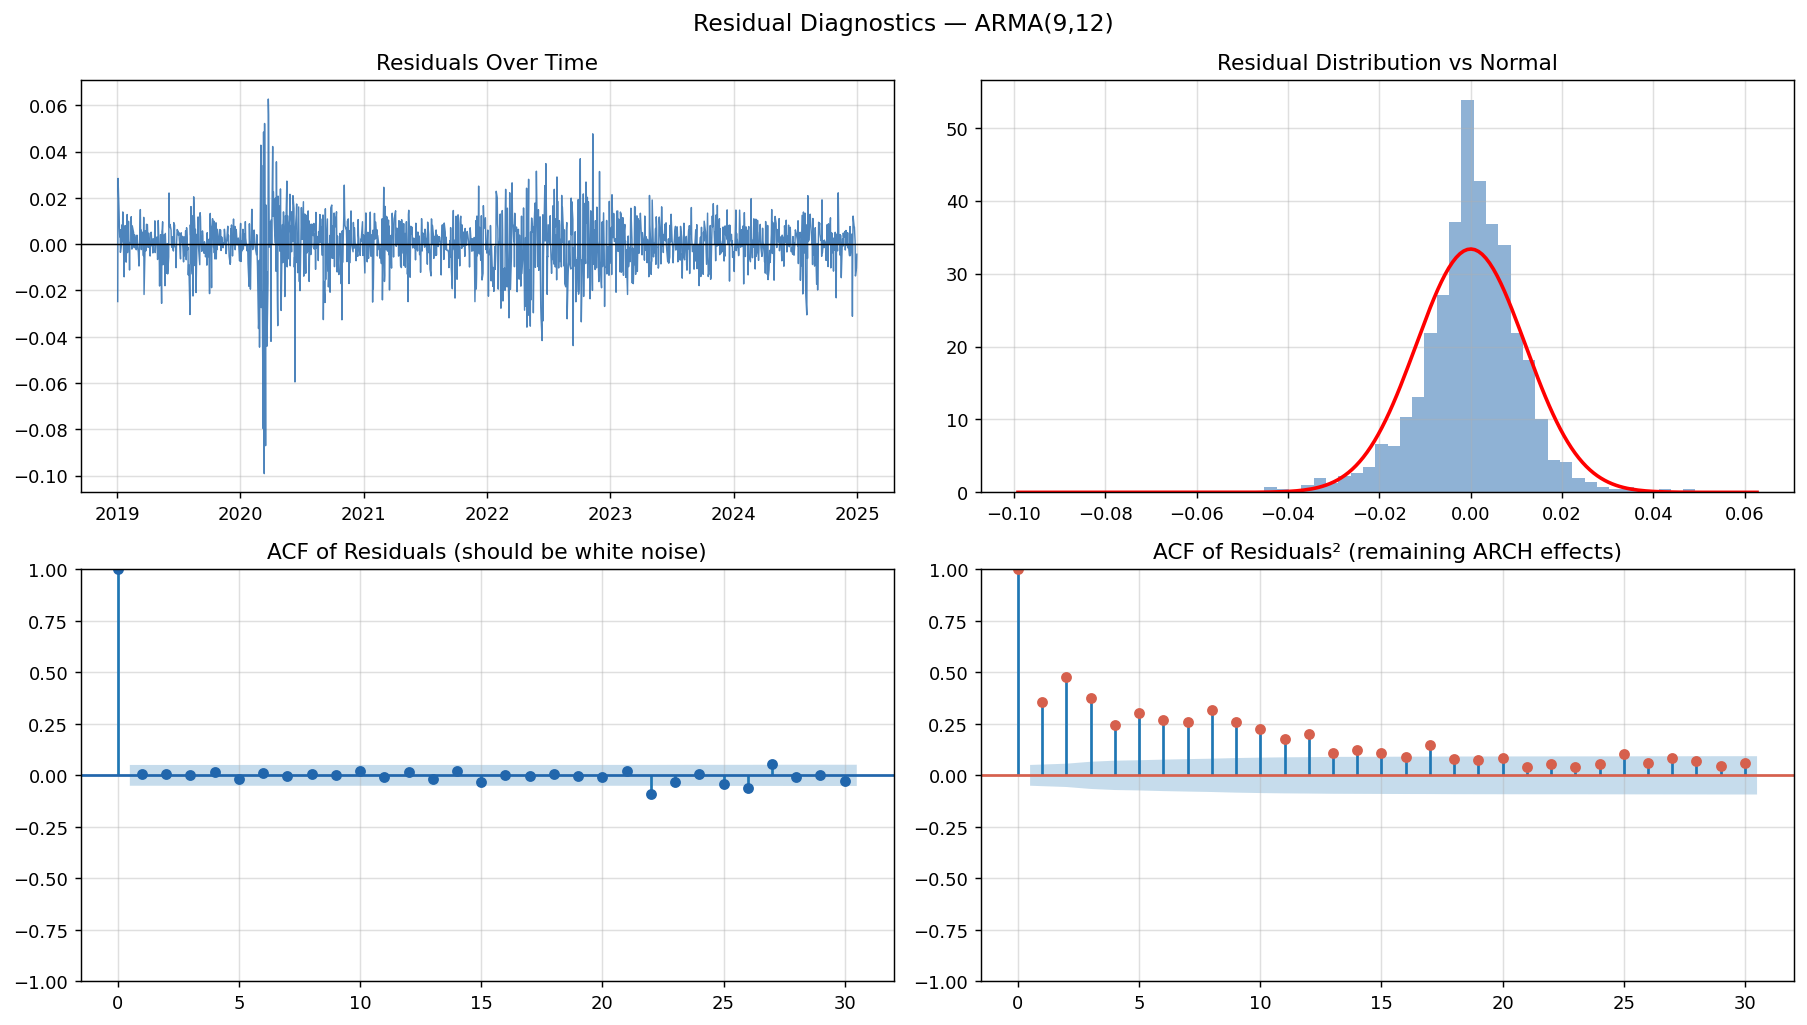


Ljung-Box on residuals:


,lb_stat,lb_pvalue
10,1.749678,0.997924
20,5.417833,0.999486



ARCH-LM (lag=10): stat=484.5531, p=0.000000 → ARCH remaining: True


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Residuals over time
axes[0, 0].plot(residuals, color=BLUE, lw=0.8, alpha=0.8)
axes[0, 0].axhline(0, color='black', lw=0.8)
axes[0, 0].set_title('Residuals Over Time')

# Residual histogram vs Normal
x = np.linspace(residuals.min(), residuals.max(), 200)
axes[0, 1].hist(residuals, bins=60, density=True, color=BLUE, alpha=0.5)
axes[0, 1].plot(x, stats.norm.pdf(x, residuals.mean(), residuals.std()), 'r-', lw=2)
axes[0, 1].set_title('Residual Distribution vs Normal')

# ACF of residuals — should be white noise
plot_acf(residuals, lags=30, ax=axes[1, 0], color=BLUE)
axes[1, 0].set_title('ACF of Residuals (should be white noise)')

# ACF of squared residuals — ARCH effects remaining
plot_acf(residuals**2, lags=30, ax=axes[1, 1], color=RED)
axes[1, 1].set_title('ACF of Residuals² (remaining ARCH effects)')

fig.suptitle(f'Residual Diagnostics — ARMA({best_p_arma},{best_q_arma})', fontsize=13)
fig.tight_layout()
plt.savefig('fig_benchmark_residuals.png', bbox_inches='tight')
plt.show()

# Formal tests
lb   = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
arch = het_arch(residuals, nlags=10)
print('\nLjung-Box on residuals:')
display(lb)
print(f'\nARCH-LM (lag=10): stat={arch[0]:.4f}, p={arch[1]:.6f} → ARCH remaining: {arch[1]<0.05}')

## 8. Forecast vs Actual Plot

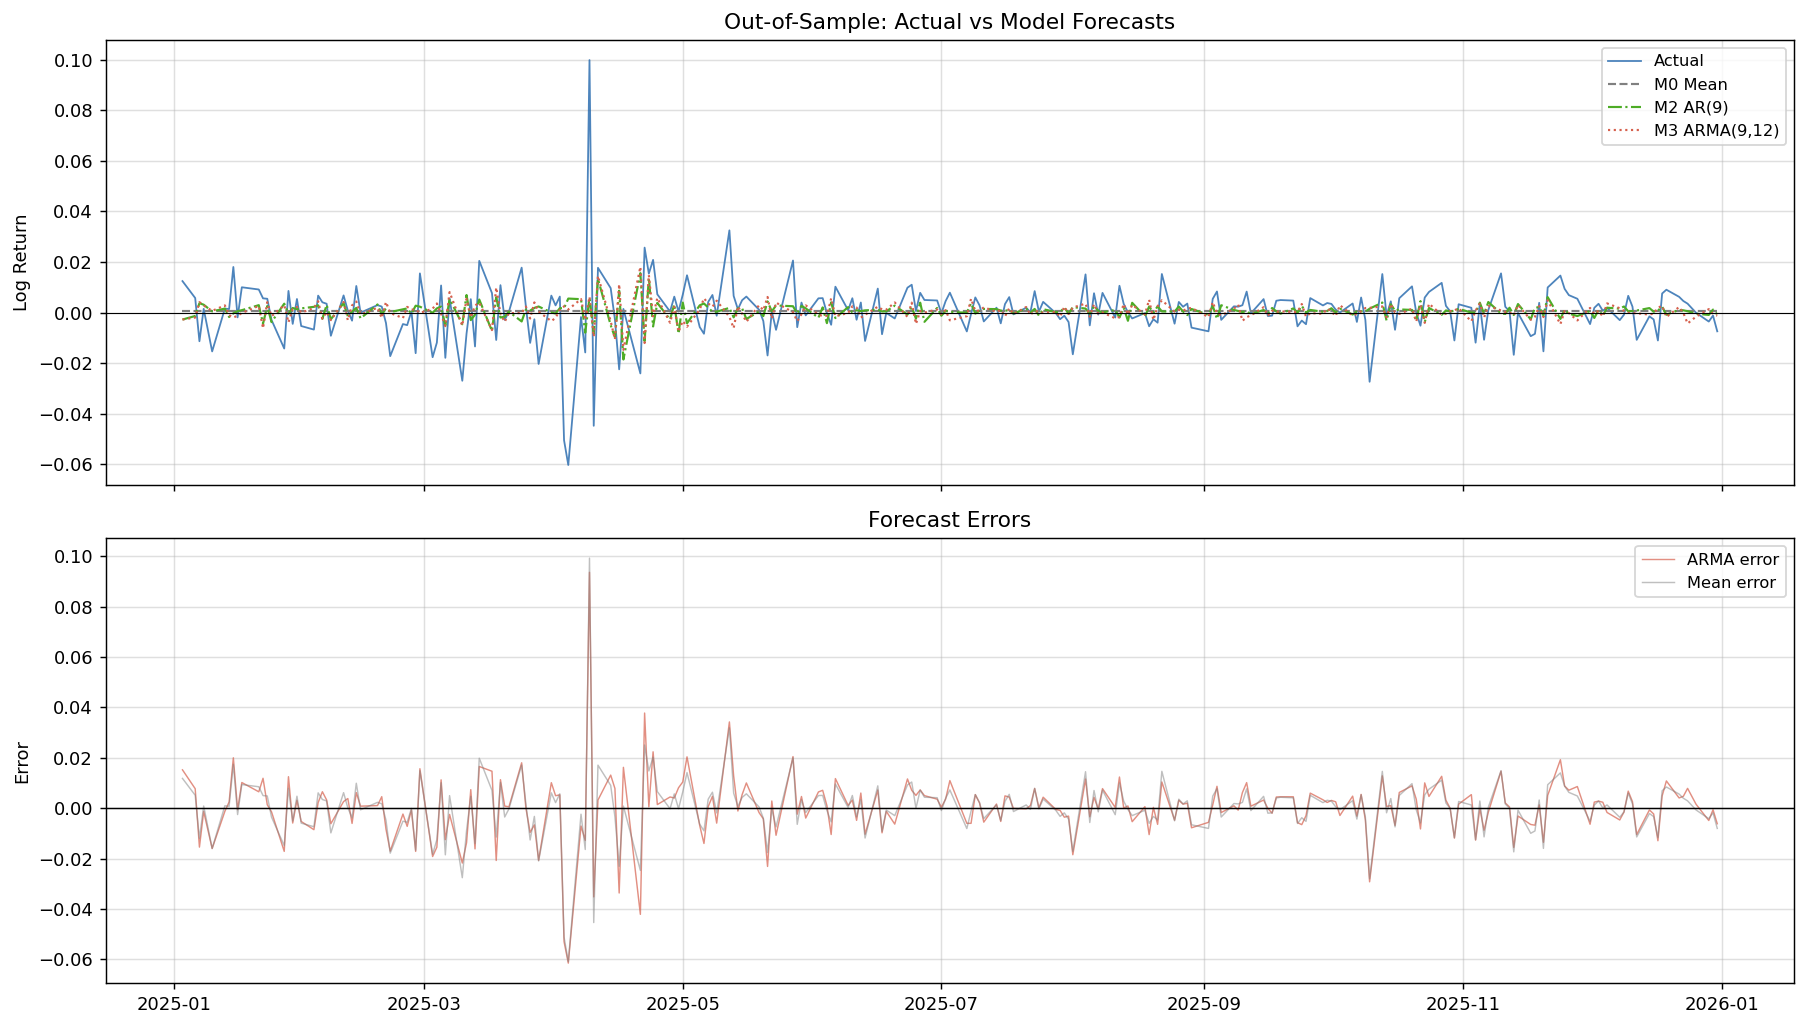

In [20]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(test.index, test,           color=BLUE,   lw=1,   label='Actual', alpha=0.8)
axes[0].plot(test.index, mean_forecast,  color='grey', lw=1.2, ls='--', label='M0 Mean')
axes[0].plot(test.index, ar_forecast,    color=GREEN,  lw=1.2, ls='-.',  label=f'M2 AR({best_p})')
axes[0].plot(test.index, arma_forecast,  color=RED,    lw=1.2, ls=':',   label=f'M3 ARMA({best_p_arma},{best_q_arma})')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_title('Out-of-Sample: Actual vs Model Forecasts')
axes[0].legend(fontsize=9)
axes[0].set_ylabel('Log Return')

# Forecast errors
axes[1].plot(test.index, test - arma_forecast, color=RED, lw=0.8, alpha=0.7, label='ARMA error')
axes[1].plot(test.index, test - mean_forecast, color='grey', lw=0.8, alpha=0.5, label='Mean error')
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_title('Forecast Errors')
axes[1].legend(fontsize=9)
axes[1].set_ylabel('Error')

fig.tight_layout()
plt.savefig('fig_benchmark_forecast.png', bbox_inches='tight')
plt.show()

## 9. Model Comparison Table

In [25]:
results_df = pd.DataFrame(results).set_index('Model')

display(
    results_df.style
    .format({
        'RMSE'        : '{:.6f}',
        'MAE'         : '{:.6f}',
        'MAPE (%)'    : '{:.2f}',
        'Dir. Acc (%)': '{:.2f}',
        "Theil's U"   : '{:.4f}',
    })
    .highlight_min(subset=['RMSE', 'MAE','MAPE (%)', "Theil's U"], color='lightgreen')
    .highlight_max(subset=['Dir. Acc (%)'], color='lightgreen')
)

print("""
Metric guide:
  RMSE / MAE     : lower is better — penalise forecast errors
  MAPE           : lower is better — scale-free error
  Dir. Acc       : higher is better — % of correct sign predictions
  Theil's U < 1  : model beats naive random walk
  Theil's U = 1  : equivalent to random walk
  Theil's U > 1  : worse than random walk
""")

,RMSE,MAE,MAPE (%),Dir. Acc (%),Theil's U
Model,,,,,
M0 — Historical Mean,0.012173,0.007408,148.64,57.43,0.6605
M1 — Random Walk,0.018420,0.011251,787.90,49.40,0.9995
M2 — AR(9),0.012592,0.007823,309.28,51.81,0.6833
"M3 — ARMA(9,12)",0.012690,0.007970,341.04,48.19,0.6886



Metric guide:
  RMSE / MAE     : lower is better — penalise forecast errors
  MAPE           : lower is better — scale-free error
  Dir. Acc       : higher is better — % of correct sign predictions
  Theil's U < 1  : model beats naive random walk
  Theil's U = 1  : equivalent to random walk
  Theil's U > 1  : worse than random walk

